In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [2]:
#basic imports just taken from hwk 4 update as seen fit?
from hashlib import sha1

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import make_column_transformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from scipy.stats import lognorm, loguniform, randint
# Hyperparameter tuning with randomized search
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

from lightgbm.sklearn import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.feature_selection import RFE, RFECV, SelectFromModel
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import shap


<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

For this project I chose option one, the classification of deafulting or not on the UCI credit card dataset. Given this is intrested in if the particular person deafults or not this would further be a binary classfication problem. After investigating the dataset it seems to be relatively decent sized but, not many extremely distinct feautures that are all numerically encoded (even the typically categorical types like Sex are encoded as 1 for male and 2 for female). The features are all accounting the same things mainly just differing temporally. 

In [3]:
df = pd.read_csv("data/UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [4]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=123)
train_df.shape

(21000, 25)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

initial observations:  
- The data is not very clean and doesnt really match with the kaggle like I expected it to based on the data description. why are there 2 unknown education levels 5 and 6? PAY feautures description doesn't include what -2 and 0 are?
- Very few features to work with.
- apparent class imbalance and we need to deal with it. I decided to use  macro average f1 as target metric so that both classes get equal weight and mitigate the issue. 
- The feature ranges are very different! (seen why I ended up making seperate plots for large and small values)
- a lot of collinear features.
- a lot of few outliers. 

In [5]:
train_df.info

<bound method DataFrame.info of           ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
16395  16396   320000.0    2          1         2   36      0      0      0   
21448  21449   440000.0    2          1         2   30     -1     -1     -1   
20034  20035   160000.0    2          3         1   44     -2     -2     -2   
25755  25756   120000.0    2          2         1   30      0      0      0   
1438    1439    50000.0    1          2         2   54      1      2      0   
...      ...        ...  ...        ...       ...  ...    ...    ...    ...   
28636  28637   380000.0    2          2         1   37      0      0      0   
17730  17731   360000.0    2          1         1   54      1     -2     -2   
28030  28031    50000.0    2          3         1   29      0      0      0   
15725  15726    30000.0    2          2         2   21      0      0      0   
19966  19967   370000.0    2          1         1   36     -2     -2     -2   

       PAY_4  ...  

In [6]:
train_df.describe

<bound method NDFrame.describe of           ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
16395  16396   320000.0    2          1         2   36      0      0      0   
21448  21449   440000.0    2          1         2   30     -1     -1     -1   
20034  20035   160000.0    2          3         1   44     -2     -2     -2   
25755  25756   120000.0    2          2         1   30      0      0      0   
1438    1439    50000.0    1          2         2   54      1      2      0   
...      ...        ...  ...        ...       ...  ...    ...    ...    ...   
28636  28637   380000.0    2          2         1   37      0      0      0   
17730  17731   360000.0    2          1         1   54      1     -2     -2   
28030  28031    50000.0    2          3         1   29      0      0      0   
15725  15726    30000.0    2          2         2   21      0      0      0   
19966  19967   370000.0    2          1         1   36     -2     -2     -2   

       PAY_4  ...

In [7]:
# check the target variable distrib
print("Target class distribution:")
print(train_df["default.payment.next.month"].value_counts(normalize=True))

Target class distribution:
default.payment.next.month
0    0.776762
1    0.223238
Name: proportion, dtype: float64


In [8]:
# Set up eval metric
from sklearn.metrics import f1_score, make_scorer

#macro F1 to handle class imbalance
scoring_metric = make_scorer(f1_score, average="macro")

In [9]:
#feature maximum values
train_df.max(axis=0)

ID                              30000.0
LIMIT_BAL                     1000000.0
SEX                                 2.0
EDUCATION                           6.0
MARRIAGE                            3.0
AGE                                79.0
PAY_0                               8.0
PAY_2                               8.0
PAY_3                               8.0
PAY_4                               8.0
PAY_5                               8.0
PAY_6                               8.0
BILL_AMT1                      964511.0
BILL_AMT2                      983931.0
BILL_AMT3                      855086.0
BILL_AMT4                      891586.0
BILL_AMT5                      927171.0
BILL_AMT6                      961664.0
PAY_AMT1                       873552.0
PAY_AMT2                      1227082.0
PAY_AMT3                       896040.0
PAY_AMT4                       621000.0
PAY_AMT5                       426529.0
PAY_AMT6                       528666.0
default.payment.next.month          1.0


In [10]:
#feature minimum values  
train_df.min(axis=0)

ID                                 1.0
LIMIT_BAL                      10000.0
SEX                                1.0
EDUCATION                          0.0
MARRIAGE                           0.0
AGE                               21.0
PAY_0                             -2.0
PAY_2                             -2.0
PAY_3                             -2.0
PAY_4                             -2.0
PAY_5                             -2.0
PAY_6                             -2.0
BILL_AMT1                     -15308.0
BILL_AMT2                     -67526.0
BILL_AMT3                    -157264.0
BILL_AMT4                     -50616.0
BILL_AMT5                     -61372.0
BILL_AMT6                    -339603.0
PAY_AMT1                           0.0
PAY_AMT2                           0.0
PAY_AMT3                           0.0
PAY_AMT4                           0.0
PAY_AMT5                           0.0
PAY_AMT6                           0.0
default.payment.next.month         0.0
dtype: float64

In [11]:
#train and test splits
X_train = train_df.drop(columns=["default.payment.next.month"])
y_train = train_df["default.payment.next.month"]

X_test = test_df.drop(columns=["default.payment.next.month"])
y_test = test_df["default.payment.next.month"]

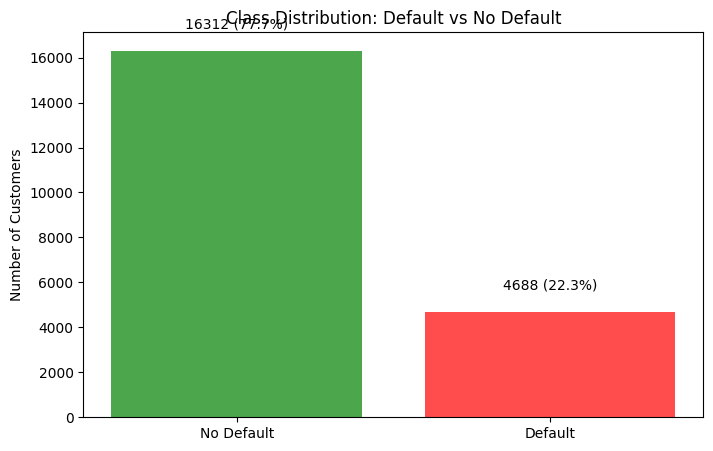

In [12]:
# imbalance in target?
plt.figure(figsize=(8, 5))
default_counts = train_df["default.payment.next.month"].value_counts()
plt.bar(['No Default', 'Default'], default_counts.values, color=['green', 'red'], alpha=0.7)
plt.title("Class Distribution: Default vs No Default")
plt.ylabel("Number of Customers")
for i, v in enumerate(default_counts.values):
    plt.text(i, v + 1000, f"{v} ({v/len(train_df)*100:.1f}%)", ha='center')
plt.show()

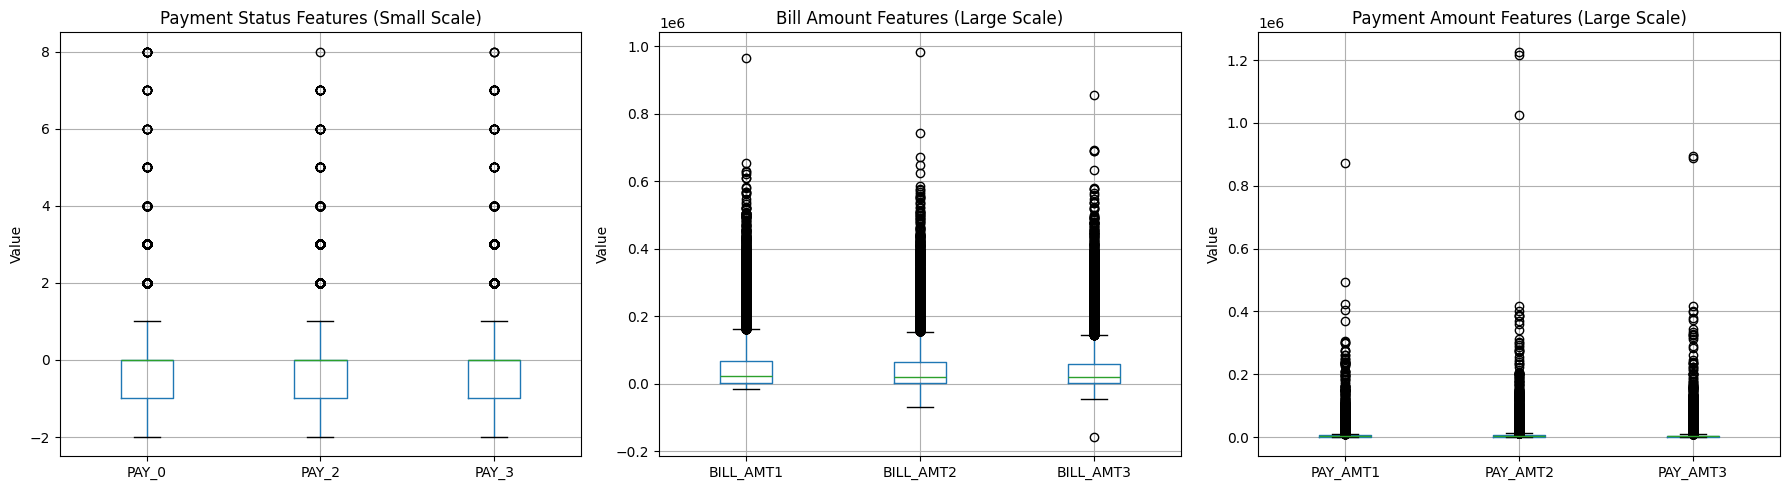

In [13]:
# feature scales across different types of features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Payment status features (small)
train_df[['PAY_0', 'PAY_2', 'PAY_3']].boxplot(ax=axes[0])
axes[0].set_title("Payment Status Features (Small Scale)")
axes[0].set_ylabel("Value")

# Bill amount features (large)
train_df[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3']].boxplot(ax=axes[1])
axes[1].set_title("Bill Amount Features (Large Scale)")
axes[1].set_ylabel("Value")

# Payment amount features (large)
train_df[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']].boxplot(ax=axes[2])
axes[2].set_title("Payment Amount Features (Large Scale)")
axes[2].set_ylabel("Value")

plt.tight_layout()
plt.show()

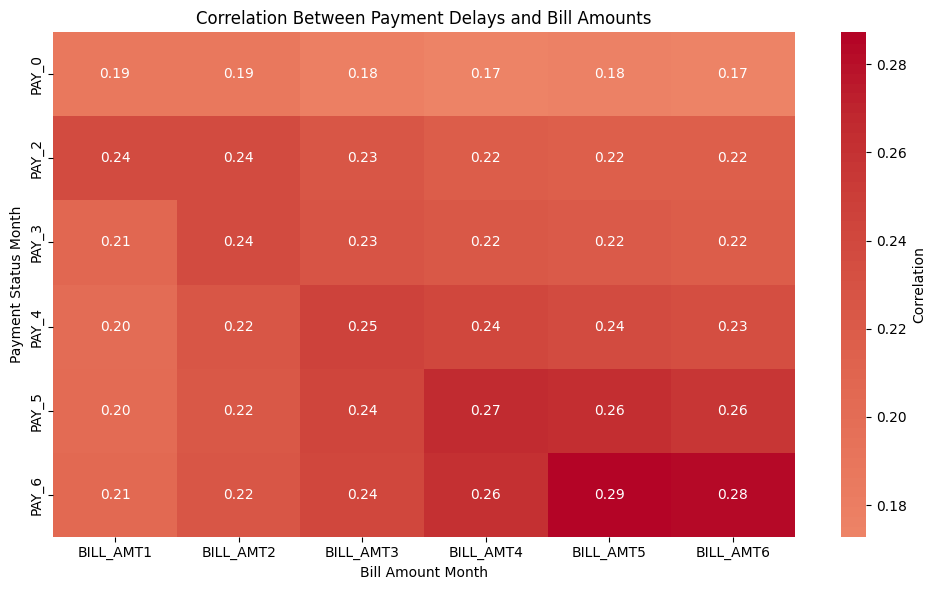

In [14]:
# corr payment delays and bill amounts
payment_delays = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_amounts = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# corr consecutive payment delays and bill amounts
corr_data = train_df[payment_delays + bill_amounts].corr()
payment_bill_corr = corr_data.loc[payment_delays, bill_amounts]

plt.figure(figsize=(10, 6))
sns.heatmap(payment_bill_corr, annot=True, cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, fmt='.2f')
plt.title("Correlation Between Payment Delays and Bill Amounts")
plt.xlabel("Bill Amount Month")
plt.ylabel("Payment Status Month")
plt.tight_layout()
plt.show()

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

In [15]:
#  .new features ON COPY DO NOT TOUCH OG
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

#total bill amount across all 6 months dont seperate temporally
X_train_eng['TOTAL_BILL'] = X_train_eng[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
                                          'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].sum(axis=1)
X_test_eng['TOTAL_BILL'] = X_test_eng[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
                                        'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].sum(axis=1)

#total payment amount across all 6 months not temporally seperate
X_train_eng['TOTAL_PAY'] = X_train_eng[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 
                                         'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].sum(axis=1)
X_test_eng['TOTAL_PAY'] = X_test_eng[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 
                                       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].sum(axis=1)

#payment ratio (ability to pay bills)
X_train_eng['PAY_RATIO'] = X_train_eng['TOTAL_PAY'] / (X_train_eng['TOTAL_BILL'] + 1)
X_test_eng['PAY_RATIO'] = X_test_eng['TOTAL_PAY'] / (X_test_eng['TOTAL_BILL'] + 1)

#average payment delay
X_train_eng['AVG_DELAY'] = X_train_eng[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].mean(axis=1)
X_test_eng['AVG_DELAY'] = X_test_eng[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].mean(axis=1)

#credi utilization
X_train_eng['UTILIZATION'] = X_train_eng['BILL_AMT1'] / (X_train_eng['LIMIT_BAL'] + 1)
X_test_eng['UTILIZATION'] = X_test_eng['BILL_AMT1'] / (X_test_eng['LIMIT_BAL'] + 1)

#update X_train and X_test
X_train = X_train_eng
X_test = X_test_eng

print(f"New features created: TOTAL_BILL, TOTAL_PAY, PAY_RATIO, AVG_DELAY, UTILIZATION")
print(f"Total features now: {X_train.shape[1]}")
X_test_eng.head()

New features created: TOTAL_BILL, TOTAL_PAY, PAY_RATIO, AVG_DELAY, UTILIZATION
Total features now: 29


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,TOTAL_BILL,TOTAL_PAY,PAY_RATIO,AVG_DELAY,UTILIZATION
25665,25666,40000.0,2,2,2,26,-1,0,0,0,...,1000.0,0.0,22373.0,680.0,10000.0,129703.0,35353.0,0.272567,-0.333333,0.724757
16464,16465,80000.0,2,3,1,59,0,0,0,0,...,2106.0,2000.0,1603.0,1903.0,2006.0,349621.0,12830.0,0.036697,0.000000,0.945763
22386,22387,170000.0,2,1,2,30,2,2,2,2,...,6500.0,0.0,13000.0,5500.0,1000.0,972809.0,32800.0,0.033717,2.000000,0.917112
10149,10150,200000.0,2,2,1,41,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,24305.0,742.0,0.030527,-2.000000,0.117849
8729,8730,50000.0,1,2,1,43,0,0,0,0,...,1150.0,331.0,341.0,356.0,330.0,53551.0,3648.0,0.068121,0.000000,0.164277


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

In [16]:
#feature types
drop_features = ["ID"] if "ID" in X_train.columns else []

numeric_features = [
    "LIMIT_BAL", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "TOTAL_BILL", "TOTAL_PAY", "PAY_RATIO", "AVG_DELAY", "UTILIZATION"
]

binary_features = ["SEX"]
categorical_features = ["EDUCATION", "MARRIAGE"]
target = "default.payment.next.month"

In [17]:
#column transformer w/ preprocessing 
preprocessor = make_column_transformer(
    ("drop", drop_features) if drop_features else ("passthrough", []),
    (StandardScaler(), numeric_features),
    (OneHotEncoder(drop="if_binary"), binary_features),
    (OneHotEncoder(handle_unknown="ignore"), categorical_features),
)

In [18]:
#fit preprocessor get feature names
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()

In [19]:
# feature names worked?
print(f"Total transformed features: {len(feature_names)}")
print(f"First 10 feature names: {feature_names[:10]}")

Total transformed features: 37
First 10 feature names: ['standardscaler__LIMIT_BAL' 'standardscaler__AGE' 'standardscaler__PAY_0'
 'standardscaler__PAY_2' 'standardscaler__PAY_3' 'standardscaler__PAY_4'
 'standardscaler__PAY_5' 'standardscaler__PAY_6'
 'standardscaler__BILL_AMT1' 'standardscaler__BILL_AMT2']


In [20]:
# cross-validation scoring
def mean_std_cross_val_scores(model, X_train, y_train, **kwargs):
    scores = cross_validate(model, X_train, y_train, **kwargs)
    mean_scores = pd.DataFrame(scores).mean()
    std_scores = pd.DataFrame(scores).std()
    out_col = []

    for i in range(len(mean_scores)):
        out_col.append((f"%0.3f (+/- %0.3f)" % (mean_scores.iloc[i], std_scores.iloc[i])))

    return pd.Series(data=out_col, index=mean_scores.index)

results = {}
results

{}

In [21]:
# dummy_pipe = make_pipeline(preprocessor, DummyClassifier())

# # check function actually works???
# mean_std_cross_val_scores(
#     dummy_pipe, 
#     X_train, 
#     y_train, 
#     cv=5, 
#     scoring=scoring_metric,
#     return_train_score=True
# )

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [22]:
#class imbalance so use strat even tho not as accurate as most freq,,,
dummy = DummyClassifier(strategy="stratified")
results["dummy"] = mean_std_cross_val_scores(
    dummy, X_train, y_train, return_train_score=True, scoring=scoring_metric
)
pd.DataFrame(results)

,dummy
fit_time,0.002 (+/- 0.002)
score_time,0.002 (+/- 0.001)
test_score,0.500 (+/- 0.010)
train_score,0.499 (+/- 0.004)


In [23]:
cross_val_score(dummy, X_train, y_train)

array([0.65261905, 0.65642857, 0.64142857, 0.66571429, 0.64833333])

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

- Logistic regression scores are considerably better than the dummy classifier scores.
- Optimizing the regularization hyperparameter C improved validation performance marginally (from ~0.635 to ~0.639) but not a lot.
- Minimal gap between train and validation scores, might be  
  underfitting not overfitting.
- Non-linear models (tree-based methods?) may be better suited for this problem and could capture more patterns in the data.

In [24]:
lr_pipeline = make_pipeline(
    preprocessor, 
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
)

results["log_reg"] = mean_std_cross_val_scores(
    lr_pipeline, X_train, y_train, return_train_score=True, scoring=scoring_metric
)

pd.DataFrame(results)

,dummy,log_reg
fit_time,0.002 (+/- 0.002),0.040 (+/- 0.003)
score_time,0.002 (+/- 0.001),0.003 (+/- 0.000)
test_score,0.500 (+/- 0.010),0.635 (+/- 0.007)
train_score,0.499 (+/- 0.004),0.636 (+/- 0.003)


In [25]:


# Define parameter distribution
param_distributions = {
    "logisticregression__C": loguniform(1e-3, 1e3)
}

# Perform randomized search
random_search_lr = RandomizedSearchCV(
    lr_pipeline,
    param_distributions,
    n_iter=50,
    cv=5,
    scoring=scoring_metric,
    random_state=42,
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

random_search_lr.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'logisticregression__C': <scipy.stats....t 0x305df2e40>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(f...average=macro)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None c

In [26]:
# Display best hyperparameters and score
print("Optimal hyperparameters:", random_search_lr.best_params_)
print("Best CV score: %.3f" % random_search_lr.best_score_)

# Show top 10 configurations
search_results = pd.DataFrame(random_search_lr.cv_results_)
top_results = search_results[
    [
        "mean_train_score",
        "mean_test_score",
        "param_logisticregression__C",
        "std_test_score",
        "mean_fit_time",
        "rank_test_score"
    ]
].set_index("rank_test_score").sort_index().head(10)

top_results

Optimal hyperparameters: {'logisticregression__C': np.float64(0.00385507369002618)}
Best CV score: 0.639


,mean_train_score,mean_test_score,param_logisticregression__C,std_test_score,mean_fit_time
rank_test_score,,,,,
1,0.638179,0.638504,0.003855,0.006824,0.046336
2,0.637681,0.637988,0.018795,0.006933,0.073048
3,0.638458,0.637816,0.005398,0.007055,0.054682
4,0.637471,0.637718,0.015778,0.006781,0.063799
5,0.638219,0.637661,0.006870,0.007293,0.056485
6,0.637652,0.637616,0.012857,0.006993,0.057705
7,0.638144,0.637580,0.008632,0.006846,0.062463
7,0.638144,0.637580,0.008629,0.006846,0.064079
9,0.637772,0.637577,0.012602,0.006926,0.063753


In [27]:
# Store tuned model results
tuned_lr = random_search_lr.best_estimator_

results["log_reg_tuned"] = mean_std_cross_val_scores(
    tuned_lr, X_train, y_train, return_train_score=True, scoring=scoring_metric
)

# Display all results
pd.DataFrame(results).T

,fit_time,score_time,test_score,train_score
dummy,0.002 (+/- 0.002),0.002 (+/- 0.001),0.500 (+/- 0.010),0.499 (+/- 0.004)
log_reg,0.040 (+/- 0.003),0.003 (+/- 0.000),0.635 (+/- 0.007),0.636 (+/- 0.003)
log_reg_tuned,0.021 (+/- 0.002),0.003 (+/- 0.000),0.639 (+/- 0.008),0.638 (+/- 0.003)


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

The dummy model performs at ~0.50, while lr improves performance to ~0.64 with no signs of overfitting, as train and test scores are nearly the same. Among the non-linear models, LGBM gets the best test score at 0.694 and outperforming both the untuned and tuned logistic regression models.he random Forest  overfits showing high variance while XGBoost also shows moderate overfitting (0.890 vs 0.676). The RBF SVM performs well but has the highest fit and score times, making it computationally expensive. Overall, tree-based boosting (especially LGBM) provided the best balance overall between generalization performance and computational efficiency.

In [28]:
ratio = np.bincount(y_train)[0] / np.bincount(y_train)[1]
ratio

models = {
    "RBF SVM": SVC(),
    "random forest": RandomForestClassifier(class_weight="balanced", random_state=2),
    "xgboost": XGBClassifier(scale_pos_weight=ratio, random_state=2),
    "lgbm": LGBMClassifier(scale_pos_weight=ratio, random_state=2, verbose=-1),
}

for name, model in models.items():
    pipe = make_pipeline(preprocessor, model)
    results[name] = mean_std_cross_val_scores(
        pipe, X_train, y_train, return_train_score=True, scoring=scoring_metric
    )

pd.DataFrame(results).T

/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fit

,fit_time,score_time,test_score,train_score
dummy,0.002 (+/- 0.002),0.002 (+/- 0.001),0.500 (+/- 0.010),0.499 (+/- 0.004)
log_reg,0.040 (+/- 0.003),0.003 (+/- 0.000),0.635 (+/- 0.007),0.636 (+/- 0.003)
log_reg_tuned,0.021 (+/- 0.002),0.003 (+/- 0.000),0.639 (+/- 0.008),0.638 (+/- 0.003)
RBF SVM,3.144 (+/- 0.029),1.376 (+/- 0.068),0.675 (+/- 0.008),0.685 (+/- 0.001)
random forest,2.662 (+/- 0.034),0.045 (+/- 0.001),0.667 (+/- 0.008),0.999 (+/- 0.000)
xgboost,0.187 (+/- 0.001),0.006 (+/- 0.000),0.676 (+/- 0.008),0.890 (+/- 0.006)
lgbm,0.427 (+/- 0.014),0.008 (+/- 0.001),0.694 (+/- 0.008),0.785 (+/- 0.004)


In [29]:
del models["RBF SVM"]

In [30]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

Total 30 features were selected by the regularization and pretty minimal improvements with lrand regularization but not a lot although do not have a large number of features in general so just abandon feature selection from the pipeline

In [31]:
for name, model in models.items():
    pipe = make_pipeline(
        preprocessor,
        SelectFromModel(
            LogisticRegression(solver="liblinear", penalty="l1", max_iter=1000)
        ),
        model,
    )
    results[name + "+ feat_sel"] = mean_std_cross_val_scores(
        pipe, X_train, y_train, return_train_score=True, scoring=scoring_metric
    )

    

/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and

In [32]:
pipe_random_forest = make_pipeline(
    preprocessor,
    SelectFromModel(
        LogisticRegression(solver="liblinear", penalty="l1", max_iter=1000)
    ),
    models["random forest"],
)

pipe_random_forest.fit(X_train, y_train)
print(
    "features selected: ",
    pipe_random_forest.named_steps["randomforestclassifier"].n_features_in_,
)

/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


features selected:  31


In [33]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

Hyperparameter optimization seems to help with random forests as well as LightGBM. The scores for both models seem very similar but i picked LightGBM because;
- it seems to be less overfitting 
- it's much faster (on my computer atleast)
- the standard deviation is smaller compared to random forest. 

In [34]:
param_grid_rf = {
    "randomforestclassifier__n_estimators": randint(low=10, high=100),
    "randomforestclassifier__max_depth": randint(low=2, high=20),
}

pipe_random_forest = make_pipeline(preprocessor, models["random forest"])

In [35]:
random_search_rf = RandomizedSearchCV(
    pipe_random_forest,
    param_grid_rf,
    n_iter=50,
    verbose=1,
    n_jobs=1,
    scoring=scoring_metric,
    random_state=123,
    return_train_score=True,
)

random_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=2))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'randomforestclassifier__max_depth': <scipy.stats....t 0x30ed6da90>, 'randomforestclassifier__n_estimators': <scipy.stats....t 0x305fa2a50>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(f...average=macro)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation str

In [36]:
print("Best hyperparameter values: ", random_search_rf.best_params_)
print("Best score: %0.3f" % (random_search_rf.best_score_))

pd.DataFrame(random_search_rf.cv_results_)[
    [
        "mean_train_score",
        "mean_test_score",
        "param_randomforestclassifier__n_estimators",
        "param_randomforestclassifier__max_depth",
        "mean_fit_time",
        "rank_test_score",
        "std_test_score",
    ]
].set_index("rank_test_score").sort_index()[:10]

Best hyperparameter values:  {'randomforestclassifier__max_depth': 9, 'randomforestclassifier__n_estimators': 76}
Best score: 0.705


,mean_train_score,mean_test_score,param_randomforestclassifier__n_estimators,param_randomforestclassifier__max_depth,mean_fit_time,std_test_score
rank_test_score,,,,,,
1,0.760281,0.704534,76,9,1.235812,0.008584
2,0.779357,0.703259,35,10,0.629621,0.007787
3,0.804195,0.701842,42,11,0.807857,0.009660
4,0.830210,0.701666,79,12,1.604375,0.011287
5,0.805194,0.701633,62,11,1.183889,0.010821
6,0.858233,0.701543,68,13,1.448642,0.008531
7,0.742047,0.701412,95,8,1.418109,0.007962
8,0.830379,0.700870,67,12,1.354618,0.010692
9,0.829390,0.700707,32,12,0.661718,0.012002


In [37]:
best_rf_model = random_search_rf.best_estimator_
results["random forest (tuned)"] = mean_std_cross_val_scores(
    best_rf_model, X_train, y_train, return_train_score=True, scoring=scoring_metric
)
pd.DataFrame(results).T

,fit_time,score_time,test_score,train_score
dummy,0.002 (+/- 0.002),0.002 (+/- 0.001),0.500 (+/- 0.010),0.499 (+/- 0.004)
log_reg,0.040 (+/- 0.003),0.003 (+/- 0.000),0.635 (+/- 0.007),0.636 (+/- 0.003)
log_reg_tuned,0.021 (+/- 0.002),0.003 (+/- 0.000),0.639 (+/- 0.008),0.638 (+/- 0.003)
RBF SVM,3.144 (+/- 0.029),1.376 (+/- 0.068),0.675 (+/- 0.008),0.685 (+/- 0.001)
random forest,2.662 (+/- 0.034),0.045 (+/- 0.001),0.667 (+/- 0.008),0.999 (+/- 0.000)
xgboost,0.187 (+/- 0.001),0.006 (+/- 0.000),0.676 (+/- 0.008),0.890 (+/- 0.006)
lgbm,0.427 (+/- 0.014),0.008 (+/- 0.001),0.694 (+/- 0.008),0.785 (+/- 0.004)
random forest+ feat_sel,3.069 (+/- 0.196),0.046 (+/- 0.002),0.671 (+/- 0.008),0.999 (+/- 0.000)
xgboost+ feat_sel,0.847 (+/- 0.173),0.006 (+/- 0.001),0.679 (+/- 0.009),0.885 (+/- 0.005)
lgbm+ feat_sel,1.095 (+/- 0.242),0.008 (+/- 0.000),0.693 (+/- 0.009),0.782 (+/- 0.003)


In [38]:
param_grid_lgbm = {
    "lgbmclassifier__n_estimators": randint(10, 100),
    # "lgbmclassifier__max_depth": randint(low=2, high=20),
    "lgbmclassifier__learning_rate": [0.01, 0.1],
    "lgbmclassifier__subsample": [0.5, 0.75, 1],
}

pipe_lgbm = make_pipeline(
    preprocessor,
    models["lgbm"],
)

In [39]:
random_search_lgbm = RandomizedSearchCV(
    pipe_lgbm,
    param_grid_lgbm,
    n_iter=50,
    verbose=1,
    n_jobs=1,
    scoring=scoring_metric,
    random_state=123,
    return_train_score=True,
)

random_search_lgbm.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fit

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'lgbmclassifier__learning_rate': [0.01, 0.1], 'lgbmclassifier__n_estimators': <scipy.stats....t 0x30ee34050>, 'lgbmclassifier__subsample': [0.5, 0.75, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(f...average=macro)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscros

In [40]:
print("Best hyperparameter values: ", random_search_lgbm.best_params_)
print("Best score: %0.3f" % (random_search_lgbm.best_score_))

pd.DataFrame(random_search_lgbm.cv_results_)[
    [
        "mean_train_score",
        "mean_test_score",
        "param_lgbmclassifier__n_estimators",
        "param_lgbmclassifier__learning_rate",
        "param_lgbmclassifier__subsample",
        "mean_fit_time",
        "rank_test_score",
    ]
].set_index("rank_test_score").sort_index()[:10]

Best hyperparameter values:  {'lgbmclassifier__learning_rate': 0.1, 'lgbmclassifier__n_estimators': 13, 'lgbmclassifier__subsample': 0.5}
Best score: 0.712


,mean_train_score,mean_test_score,param_lgbmclassifier__n_estimators,param_lgbmclassifier__learning_rate,param_lgbmclassifier__subsample,mean_fit_time
rank_test_score,,,,,,
1,0.722434,0.711742,13,0.10,0.50,0.078132
2,0.721457,0.710990,11,0.10,1.00,0.069224
2,0.721457,0.710990,11,0.10,0.50,0.068978
4,0.723986,0.707670,17,0.10,1.00,0.095445
5,0.715250,0.703892,94,0.01,0.50,0.433857
6,0.725687,0.703384,22,0.10,1.00,0.116550
7,0.708678,0.701569,86,0.01,0.50,0.396578
8,0.727053,0.701523,24,0.10,1.00,0.127618
9,0.702337,0.696489,80,0.01,0.75,0.369597


In [41]:
best_lgbm_model = random_search_lgbm.best_estimator_
results["lgbm (tuned)"] = mean_std_cross_val_scores(
    best_lgbm_model, X_train, y_train, return_train_score=True, scoring=scoring_metric
)
pd.DataFrame(results).T

/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fit

,fit_time,score_time,test_score,train_score
dummy,0.002 (+/- 0.002),0.002 (+/- 0.001),0.500 (+/- 0.010),0.499 (+/- 0.004)
log_reg,0.040 (+/- 0.003),0.003 (+/- 0.000),0.635 (+/- 0.007),0.636 (+/- 0.003)
log_reg_tuned,0.021 (+/- 0.002),0.003 (+/- 0.000),0.639 (+/- 0.008),0.638 (+/- 0.003)
RBF SVM,3.144 (+/- 0.029),1.376 (+/- 0.068),0.675 (+/- 0.008),0.685 (+/- 0.001)
random forest,2.662 (+/- 0.034),0.045 (+/- 0.001),0.667 (+/- 0.008),0.999 (+/- 0.000)
xgboost,0.187 (+/- 0.001),0.006 (+/- 0.000),0.676 (+/- 0.008),0.890 (+/- 0.006)
lgbm,0.427 (+/- 0.014),0.008 (+/- 0.001),0.694 (+/- 0.008),0.785 (+/- 0.004)
random forest+ feat_sel,3.069 (+/- 0.196),0.046 (+/- 0.002),0.671 (+/- 0.008),0.999 (+/- 0.000)
xgboost+ feat_sel,0.847 (+/- 0.173),0.006 (+/- 0.001),0.679 (+/- 0.009),0.885 (+/- 0.005)
lgbm+ feat_sel,1.095 (+/- 0.242),0.008 (+/- 0.000),0.693 (+/- 0.009),0.782 (+/- 0.003)


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

- From the analysis above we observe that PAY_\d{0,2,3,4}, PAY_AMT, LIM_BAL features seem to be one of the most important features with `PAY_0` being the topmost feature. 
- The SHAP dependence plot demonstrates that the class is likely to be 0 (non default) for higher values for LIMIT_BAL, which makes sense.
- The features `EDUCATION` and `SEX` doesn't seem to influence the prediction much. This might be because of the noise in the `EDUCATION` column; there are a number of unknown values in this column.  

In [42]:
preprocessor.fit(X_train, y_train)

X_train_enc = pd.DataFrame(
    data=preprocessor.transform(X_train),
    columns=feature_names,
    index=X_train.index,
)

X_train_enc.head()

,standardscaler__LIMIT_BAL,standardscaler__AGE,standardscaler__PAY_0,standardscaler__PAY_2,standardscaler__PAY_3,standardscaler__PAY_4,standardscaler__PAY_5,standardscaler__PAY_6,standardscaler__BILL_AMT1,standardscaler__BILL_AMT2,...,onehotencoder-2__EDUCATION_1,onehotencoder-2__EDUCATION_2,onehotencoder-2__EDUCATION_3,onehotencoder-2__EDUCATION_4,onehotencoder-2__EDUCATION_5,onehotencoder-2__EDUCATION_6,onehotencoder-2__MARRIAGE_0,onehotencoder-2__MARRIAGE_1,onehotencoder-2__MARRIAGE_2,onehotencoder-2__MARRIAGE_3
16395,1.168355,0.054187,0.013770,0.114774,0.143483,0.192754,0.232531,0.257059,-0.300665,-0.293394,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
21448,2.090017,-0.597108,-0.878738,-0.722412,-0.692571,0.192754,0.232531,0.257059,-0.685307,-0.679495,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
20034,-0.060527,0.922579,-1.771246,-1.559598,-1.528626,-1.518801,-1.526210,-1.485154,-0.696132,-0.688319,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
25755,-0.367748,-0.597108,0.013770,0.114774,0.143483,0.192754,0.232531,0.257059,0.687456,0.752583,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1438,-0.905384,2.008070,0.906278,1.789147,0.143483,0.192754,0.232531,0.257059,-0.040230,-0.031399,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [43]:
lgbm_tuned = LGBMClassifier(
    scale_pos_weight=ratio,
    random_state=2,
    learning_rate=random_search_lgbm.best_params_["lgbmclassifier__learning_rate"],
    n_estimators=random_search_lgbm.best_params_["lgbmclassifier__n_estimators"],
    subsample=random_search_lgbm.best_params_["lgbmclassifier__subsample"],
)

lgbm_tuned.fit(X_train_enc, y_train)
lgbm_explainer = shap.TreeExplainer(lgbm_tuned)
lgbm_shap_values = lgbm_explainer.shap_values(X_train_enc)

/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [44]:
values = np.abs(lgbm_shap_values[0]).mean(0)
pd.DataFrame(data=values, index=feature_names, columns=["SHAP"]).sort_values(
    by="SHAP", ascending=False
)[:10]

,SHAP
standardscaler__LIMIT_BAL,0.031045
standardscaler__PAY_AMT6,0.031045
standardscaler__TOTAL_PAY,0.031045
standardscaler__PAY_RATIO,0.031045
standardscaler__AVG_DELAY,0.031045
standardscaler__UTILIZATION,0.031045
onehotencoder-1__SEX_2,0.031045
onehotencoder-2__EDUCATION_0,0.031045
onehotencoder-2__EDUCATION_1,0.031045
onehotencoder-2__EDUCATION_2,0.031045


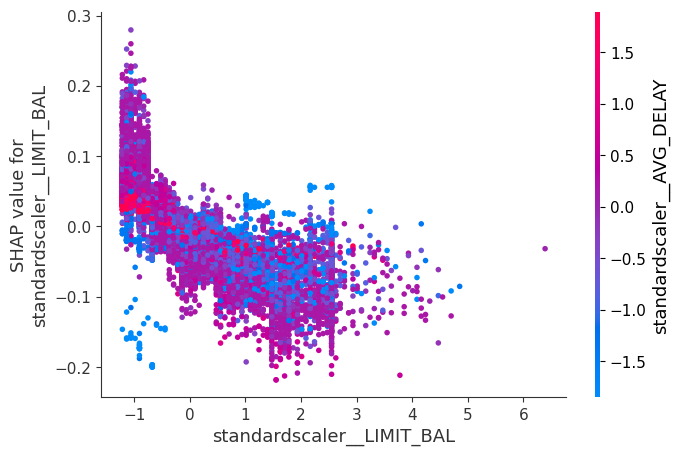

In [45]:
shap.dependence_plot("standardscaler__LIMIT_BAL", lgbm_shap_values, X_train_enc)

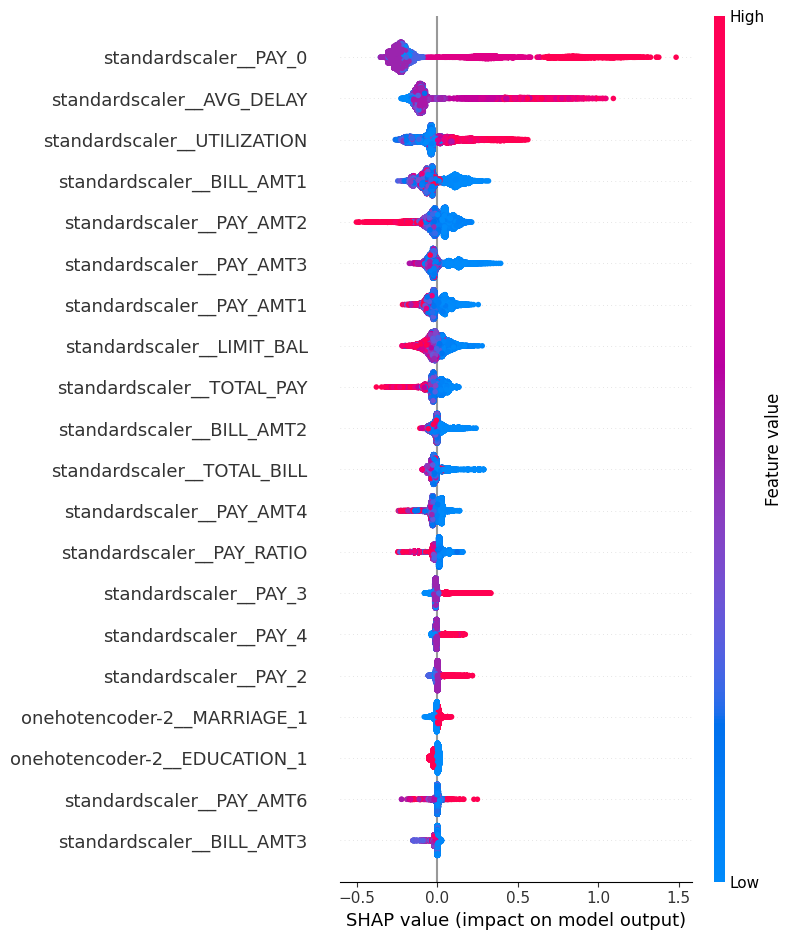

In [46]:
shap.summary_plot(lgbm_shap_values, X_train_enc)

In [47]:
X_test_enc = pd.DataFrame(
    data=preprocessor.transform(X_test),
    columns=feature_names,
    index=X_test.index,
)

test_lgbm_shap_values = lgbm_explainer.shap_values(X_test_enc)

/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [48]:
lgbm_tuned.predict_proba(X_test_enc)[1]

array([0.68984202, 0.31015798])

In [49]:
lgbm_tuned.predict(X_test_enc, raw_score=True)[1]

np.float64(-0.7993808378465321)

In [50]:
lgbm_explainer.expected_value

np.float64(-0.5693449231846913)

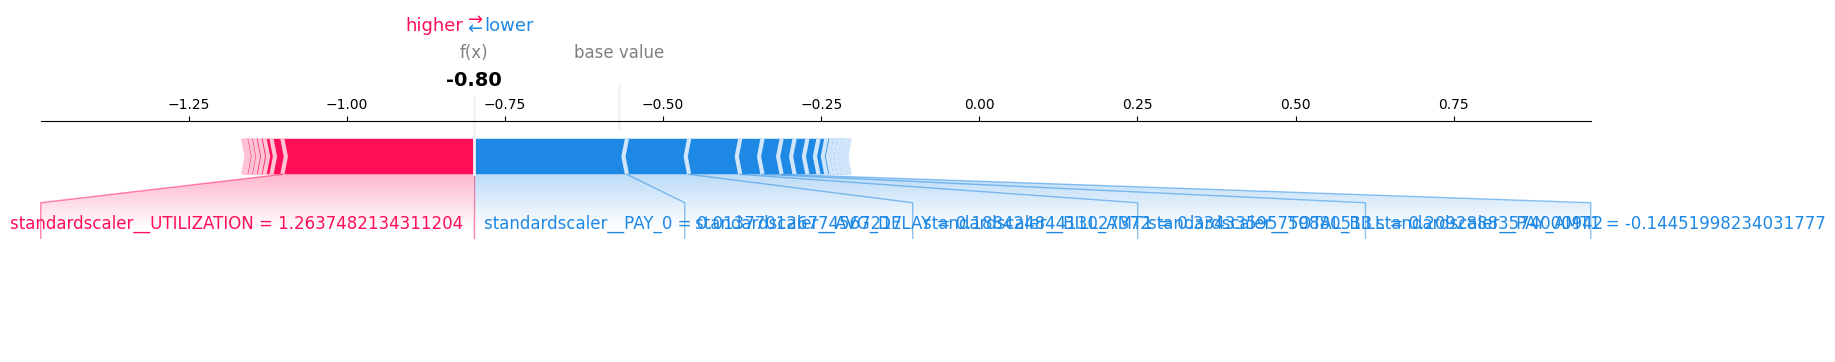

In [51]:
shap.force_plot(
    lgbm_explainer.expected_value,
    test_lgbm_shap_values[1, :],
    X_test_enc.iloc[1, :],
    matplotlib=True,
)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

- The macro-average f1-score (0.695) on the held-out test set is pretty much in line with the macro-average f1-score validation score (0.707). So there doesn't seem to be severe optimization bias here.
The raw model score is -0.84, which is smaller than the base value -0.5594 and so the prediction is that the user is not likely to default on credit payment.  
The raw model score is 1.00, which is greater than the base value -0.5594 and so the prediction is that the user is likely to default on the credit payment (class 1). 
- Positive values for PAY_* variables seem to push the prediction towards a higher value. 

In [52]:
best_model = random_search_lgbm.best_estimator_
print(
    "grid Search best model score: %0.3f" % (random_search_lgbm.best_score_)
)

predictions = best_model.predict(X_test)
print(
    "average f1 score on the test set: %0.3f"
    % (f1_score(y_test, predictions, average="macro"))
)

grid Search best model score: 0.712
average f1 score on the test set: 0.697


/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


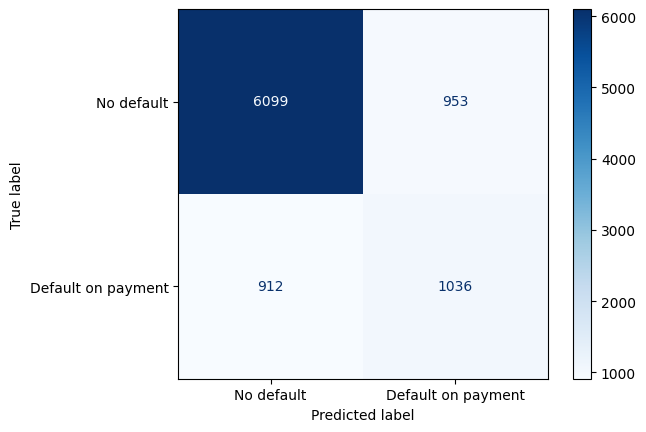

In [53]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["No default", "Default on payment"],
    values_format="d",
    cmap=plt.cm.Blues,
)

In [54]:
print(
    classification_report(
        y_test, predictions, target_names=["No default", "defaults payment"]
    )
)

                  precision    recall  f1-score   support

      No default       0.87      0.86      0.87      7052
defaults payment       0.52      0.53      0.53      1948

        accuracy                           0.79      9000
       macro avg       0.70      0.70      0.70      9000
    weighted avg       0.79      0.79      0.79      9000



In [55]:
y_test_reset = y_test.reset_index(drop=True)
non_default_ind = y_test_reset[y_test_reset == 0].index.tolist()
default_ind = y_test_reset[y_test_reset == 1].index.tolist()

ex_non_default_index = non_default_ind[0]
ex_default_index = default_ind[0]

In [56]:
lgbm_tuned.predict_proba(X_test_enc)[ex_non_default_index]

array([0.66373379, 0.33626621])

In [57]:
lgbm_tuned.predict(X_test_enc, raw_score=True)[ex_non_default_index]

np.float64(-0.6799780313766404)

In [58]:
lgbm_explainer.expected_value

np.float64(-0.5693449231846913)

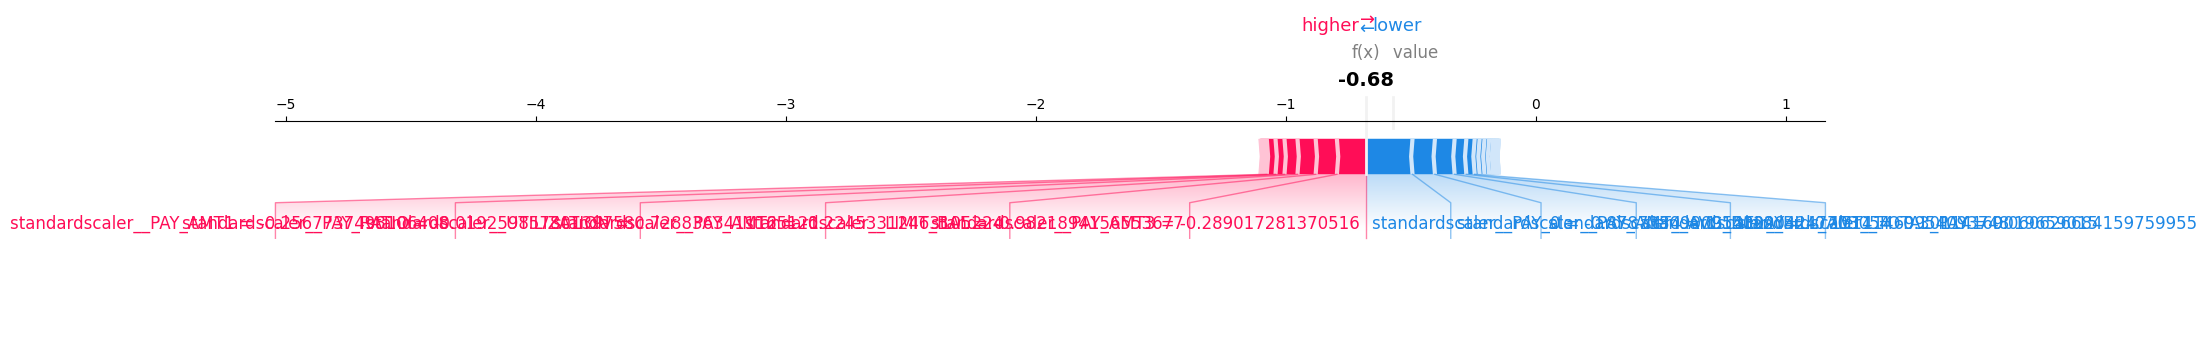

In [59]:
shap.force_plot(
    lgbm_explainer.expected_value,
    test_lgbm_shap_values[ex_non_default_index, :],
    X_test_enc.iloc[ex_non_default_index, :],
    matplotlib=True,
)

In [60]:
lgbm_tuned.predict_proba(X_test_enc)[ex_default_index]

array([0.27293935, 0.72706065])

In [61]:
lgbm_tuned.predict(X_test_enc, raw_score=True)[ex_default_index]

np.float64(0.9797602691226925)

In [62]:
lgbm_explainer.expected_value

np.float64(-0.5693449231846913)

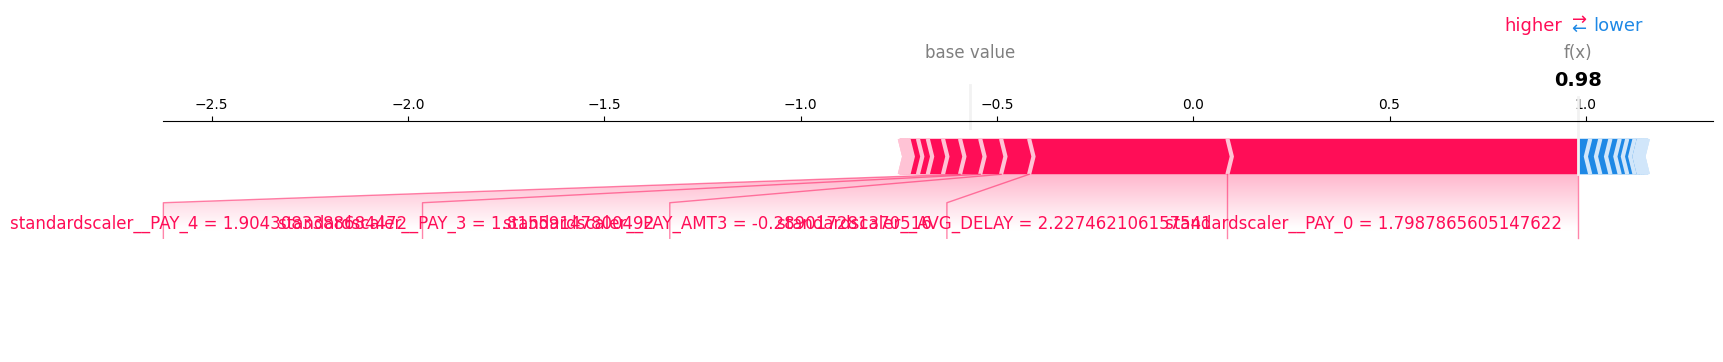

In [63]:
shap.force_plot(
    lgbm_explainer.expected_value,
    test_lgbm_shap_values[ex_default_index, :],
    X_test_enc.iloc[ex_default_index, :],
    matplotlib=True,
)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

### discussion  

All of the models did better than the baseline, which is a good sign!the best model ended up being the **LightGBM classifier** with tuned hyperparameters. It achieved a cross-validation macro-average F1 score of **0.707**. The model does not seem to overfit too much since the mean train score was **0.719** and the mean CV score was **0.707**, so the gap is not very large.  

The tuned random forest had very similar scores, but it looked like it was overfitting a bit more. It was also much slower than LightGBM. Because of that, i  chose LightGBM as the final model.

On the held-out test set, the macro-average F1 score was **0.695**, which is pretty close to the CV score of 0.707. So there does not seem to be any major optimization bias here, which is reassuring.


### feature select  

 inoticed that L1 feature selection helped slightly for the random forest model, but it did not really improve the LightGBM results when included in the pipeline. In general, this dataset has a relatively small number of features, so feature selection does not seem super critical here.

From the  feature importance analysis, the most important variables were `PAY_\d{0,2}`, `LIMIT_*`, `PAY_AMT*`  

Interestingly, the `SEX` feature did not show up as one of the most important features. However, depending on the context, it might still make sense to drop it from the analysis for fairness or ethical reasons!



### improvements  

#### Preprocessing and Feature Engineering  

- The `BILL_AMT*` and `PAY_AMT*` features represent the bill amount and the amount paid. It might be useful to create new features by subtracting these or combining them in some way, so we capture how much someone paid relative to what they owed.  
- There are quite a few collinear features in this dataset, especially the `PAY_\d{0,5}` features, which are also among the most important ones. We could try combining them into some aggregated feature.  
- More data cleaning would probably help as well.  

In my opinion, feature engineering and data cleaning are probabaly some of the most important steps here, and i didnt explore them as deeply as i could have but given the deadline i didnt.



#### hyperparameter optimization  

Because of time constraints, i did not do very extensive hyperparameter tuning. For example, i didnt really tune the XGBoost model much. It would likely be worth spending more time on that to see if performance could improve further. Overall, there is definetly room for improvement, but the current results seem reasonable and fairly stable and happy with it.

In [64]:
pd.DataFrame(results).T
summary_df = pd.DataFrame(results).T

In [65]:
comments = {
    "lgbm (tuned)": "Tuning improved performance further and gives the strongest overall results. Very similar to tuned random forest but preferred due to faster training time.",
    "random forest (tuned)": "Hyperparameter tuning made a clear difference and gave the best results at that stage.",
    "xgboost": "Strong performance and less overfitting than the random forest model.",
    "lgbm": "Slight improvement compared to XGBoost with reduced overfitting.",
    "random forest": "Improves over tuned logistic regression but shows noticeable overfitting.",
    "RBF SVM": "Performs better than tuned logistic regression, however training is quite slow.",
    "logreg (tuned)": "After tuning there is a small boost, but the model still seems to underfit overall.",
    "logreg": "Does better than the baseline but clearly still underfitting the data.",
    "random forest+ feat_sel": "Using L1-based feature selection gives a very small improvement and keeps 29 features.",
    "xgboost+ feat_sel": "Only a marginal gain from adding L1 feature selection.",
    "lgbm+ feat_sel": "No real improvement observed after applying L1 feature selection.",
    "dummy": "Serves as our baseline model with a macro-average F1 score of 0.50.",
}

pd.set_option("display.max_colwidth", 0)
summary_df["comments"] = comments.values()
summary_df

,fit_time,score_time,test_score,train_score,comments
dummy,0.002 (+/- 0.002),0.002 (+/- 0.001),0.500 (+/- 0.010),0.499 (+/- 0.004),Tuning improved performance further and gives the strongest overall results. Very similar to tuned random forest but preferred due to faster training time.
log_reg,0.040 (+/- 0.003),0.003 (+/- 0.000),0.635 (+/- 0.007),0.636 (+/- 0.003),Hyperparameter tuning made a clear difference and gave the best results at that stage.
log_reg_tuned,0.021 (+/- 0.002),0.003 (+/- 0.000),0.639 (+/- 0.008),0.638 (+/- 0.003),Strong performance and less overfitting than the random forest model.
RBF SVM,3.144 (+/- 0.029),1.376 (+/- 0.068),0.675 (+/- 0.008),0.685 (+/- 0.001),Slight improvement compared to XGBoost with reduced overfitting.
random forest,2.662 (+/- 0.034),0.045 (+/- 0.001),0.667 (+/- 0.008),0.999 (+/- 0.000),Improves over tuned logistic regression but shows noticeable overfitting.
xgboost,0.187 (+/- 0.001),0.006 (+/- 0.000),0.676 (+/- 0.008),0.890 (+/- 0.006),"Performs better than tuned logistic regression, however training is quite slow."
lgbm,0.427 (+/- 0.014),0.008 (+/- 0.001),0.694 (+/- 0.008),0.785 (+/- 0.004),"After tuning there is a small boost, but the model still seems to underfit overall."
random forest+ feat_sel,3.069 (+/- 0.196),0.046 (+/- 0.002),0.671 (+/- 0.008),0.999 (+/- 0.000),Does better than the baseline but clearly still underfitting the data.
xgboost+ feat_sel,0.847 (+/- 0.173),0.006 (+/- 0.001),0.679 (+/- 0.009),0.885 (+/- 0.005),Using L1-based feature selection gives a very small improvement and keeps 29 features.
lgbm+ feat_sel,1.095 (+/- 0.242),0.008 (+/- 0.000),0.693 (+/- 0.009),0.782 (+/- 0.003),Only a marginal gain from adding L1 feature selection.


<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

My biggest takeaway from supervised machine learning so far is that the algorithm itself is usually not the most important part. At the start, I thought choosing a powerful model like XGBoost or LightGBM was what really determined performance. But after working through the assignments, I realized that proper data splitting, preprocessing, cross-validation, and avoiding data leakage are actually much more critical. A simple model with a clean workflow can outperform a complex model with poor evaluation practices.

Another major lesson for me was how easy it is to overfit without realizing it. A model can perform extremely well on the training set, but that performance does not mean much if it does not generalize. Learning to rely on cross-validation scores and comparing them carefully to test scores changed how I evaluate results. I also understand now that small score differences are not always meaningful, especially when variability across folds exists.

Finally, I learned that machine learning is not just about optimizing metrics. Interpretation, feature importance, and ethical considerations are equally important. It is necessary to understand what drives predictions and whether certain features should even be included. Overall, supervised learning feels much more structured and careful than I originally expected, and I now see it as a full workflow rather than just fitting a model.


<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)